[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_05_kmeans_segmentacion.ipynb)

# 02_05 KMeans para segmentacion

Objetivo: construir un flujo completo y sencillo de clustering con **KMeans**, explicando como elegir el numero de clusters `k` con:

- metodo del codo,
- indice de silueta,
- indice de Calinski-Harabasz.

## 1. Intuicion de KMeans

KMeans agrupa observaciones por cercania a centroides.

- Cada cluster tiene un centro (centroide).
- Cada punto se asigna al centroide mas cercano.
- El algoritmo intenta minimizar la variacion interna de cada cluster.

> Como usa distancias, **es obligatorio estandarizar** las variables antes de entrenar.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Carga de datos y exploracion breve

Usaremos el dataset `wine` de sklearn (datos quimicos de vinos) porque es pequeno, limpio y util para practicar segmentacion.

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

feature_names = wine.feature_names
print("\nNumero de variables para clustering:", len(feature_names))
print("Variables:", feature_names)

Forma del dataset: (178, 14)

Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Numero de variables para clustering: 13
Variables: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


**Comentario:** El dataset tiene `178` filas y `14` columnas; para clustering usamos `13` variables predictoras. Es un tamano adecuado para practica y permite ver patrones sin alto costo computacional. Como las escalas entre variables son muy distintas, estandarizar no es opcional: es parte del metodo.

## 3. Estandarización

Aplicamos `StandardScaler` para que todas las variables queden comparables en escala.

In [3]:
X = df[feature_names].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Forma X escalado:", X_scaled.shape)
print("Media aproximada (primeras 5 vars):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Desv. est. aproximada (primeras 5 vars):", np.round(X_scaled.std(axis=0)[:5], 3))

Forma X escalado: (178, 13)
Media aproximada (primeras 5 vars): [-0. -0. -0. -0. -0.]
Desv. est. aproximada (primeras 5 vars): [1. 1. 1. 1. 1.]


**Comentario:** El escalamiento quedo correcto: `X_scaled` mantiene forma `(178, 13)`, con medias ~`0` y desv. estandar ~`1`. En terminos practicos, cada variable ahora aporta de forma comparable a la distancia euclidiana, evitando sesgos por unidades.

## 4. Seleccion de `k`: codo, silueta y Calinski-Harabasz

In [4]:
k_values = range(2, 11)
inertias = []
sil_scores = []
ch_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels_k))

results_k = pd.DataFrame(
    {
        "k": list(k_values),
        "inercia_wcss": inertias,
        "silhouette": sil_scores,
        "calinski_harabasz": ch_scores,
    }
)

display(results_k)

,k,inercia_wcss,silhouette,calinski_harabasz
0,2,1658.758852,0.259317,69.523332
1,3,1277.928489,0.284859,70.940008
2,4,1175.351881,0.258608,56.188782
3,5,1107.007343,0.231528,47.156356
4,6,1046.002333,0.237167,41.700786
5,7,981.595233,0.203628,38.685534
6,8,935.201211,0.157014,35.805250
7,9,889.892911,0.149882,33.806610
8,10,845.895237,0.143638,32.397182


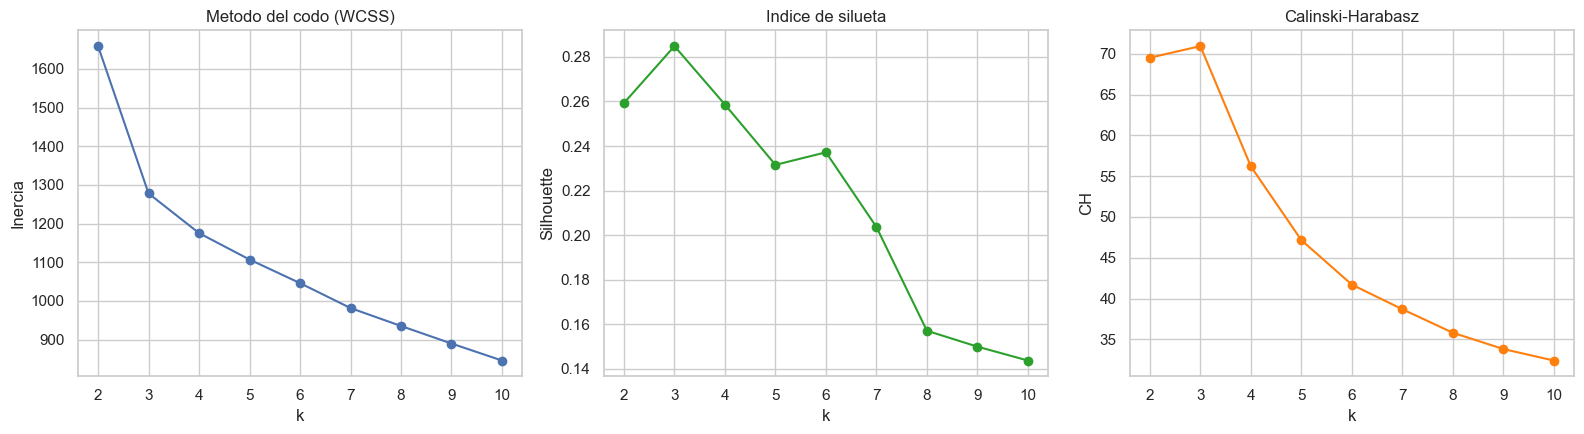

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(results_k["k"], results_k["inercia_wcss"], marker="o")
axes[0].set_title("Metodo del codo (WCSS)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(results_k["k"], results_k["silhouette"], marker="o", color="tab:green")
axes[1].set_title("Indice de silueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(results_k["k"], results_k["calinski_harabasz"], marker="o", color="tab:orange")
axes[2].set_title("Calinski-Harabasz")
axes[2].set_xlabel("k")
axes[2].set_ylabel("CH")

plt.tight_layout()
plt.show()

In [6]:
k_sil = int(results_k.loc[results_k["silhouette"].idxmax(), "k"])
k_ch = int(results_k.loc[results_k["calinski_harabasz"].idxmax(), "k"])

print(f"Mejor k por silhouette: {k_sil}")
print(f"Mejor k por Calinski-Harabasz: {k_ch}")

if k_sil == k_ch:
    k_recomendado = k_sil
else:
    k_recomendado = int(round((k_sil + k_ch) / 2))

print(f"k recomendado para entrenar modelo final: {k_recomendado}")

Mejor k por silhouette: 3
Mejor k por Calinski-Harabasz: 3
k recomendado para entrenar modelo final: 3


### Grafico detallado del metodo de silueta (k recomendado)

Este grafico permite ver, para cada cluster, la distribucion de coeficientes de silueta y su promedio global.

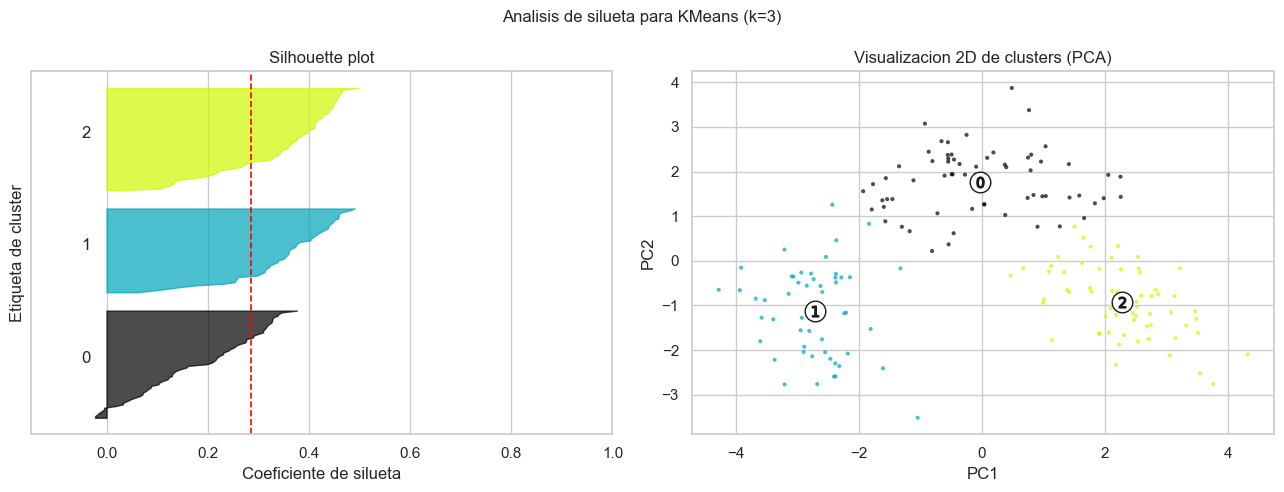

Silhouette promedio para k=3: 0.2849


In [7]:
# Analisis de silueta para k recomendado
km_sil = KMeans(n_clusters=k_recomendado, random_state=RANDOM_STATE, n_init=20)
labels_sil = km_sil.fit_predict(X_scaled)
sil_avg = silhouette_score(X_scaled, labels_sil)
sil_values = silhouette_samples(X_scaled, labels_sil)

# Proyeccion 2D para visualizacion (solo grafica)
pca_sil = PCA(n_components=2, random_state=RANDOM_STATE)
X_sil_2d = pca_sil.fit_transform(X_scaled)
centers_2d = pca_sil.transform(km_sil.cluster_centers_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Analisis de silueta para KMeans (k={k_recomendado})", fontsize=12)

# Panel izquierdo: silhouette plot
y_lower = 10
for i in range(k_recomendado):
    vals_i = sil_values[labels_sil == i]
    vals_i.sort()
    size_i = vals_i.shape[0]
    y_upper = y_lower + size_i

    color = plt.cm.nipy_spectral(float(i) / k_recomendado)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i, facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))

    y_lower = y_upper + 10

ax1.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.2)
ax1.set_title("Silhouette plot")
ax1.set_xlabel("Coeficiente de silueta")
ax1.set_ylabel("Etiqueta de cluster")
ax1.set_yticks([])
ax1.set_xlim([-0.15, 1.0])

# Panel derecho: datos clusterizados en 2D
colors = plt.cm.nipy_spectral(labels_sil.astype(float) / k_recomendado)
ax2.scatter(X_sil_2d[:, 0], X_sil_2d[:, 1], marker=".", s=35, lw=0, alpha=0.7, c=colors)
ax2.scatter(centers_2d[:, 0], centers_2d[:, 1], marker="o", c="white", alpha=1, s=220, edgecolor="k")
for i, c in enumerate(centers_2d):
    ax2.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=60, edgecolor="k")

ax2.set_title("Visualizacion 2D de clusters (PCA)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()

print(f"Silhouette promedio para k={k_recomendado}: {sil_avg:.4f}")

**Comentario:** En el silhouette plot, barras mas largas y mayormente positivas indican mejor separacion interna del cluster. La linea roja marca la silueta promedio global; en este caso, un valor alrededor de `0.28` refleja separacion moderada (aceptable para un ejemplo real, aunque no perfecta).

**Comentario:**
- El mejor `k` por **silueta** es `3` (maximo ~`0.2849`).
- El mejor `k` por **Calinski-Harabasz** tambien es `3` (maximo ~`70.94`).
- Al coincidir ambos criterios, usar `k=3` es una decision robusta.
- El codo muestra mejora fuerte en los primeros `k`; despues, la ganancia marginal disminuye. Esto refuerza que aumentar clusters mas alla de 3 no aporta tanto valor en este caso.

## 5. Entrenamiento final con `k` recomendado

In [8]:
kmeans_final = KMeans(n_clusters=k_recomendado, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans_final.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["cluster"] = clusters

print("Tamano de cada cluster:")
display(df_clusters["cluster"].value_counts().sort_index().to_frame("conteo"))

print("Promedios por cluster (primeras variables):")
display(df_clusters.groupby("cluster")[feature_names].mean().iloc[:, :6])

Tamano de cada cluster:

,conteo
cluster,
0,65
1,51
2,62


Promedios por cluster (primeras variables):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols
cluster,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581


**Comentario:** El modelo final con `k=3` produce clusters de tamano `65`, `51` y `62`, una particion balanceada para analisis. Los promedios por cluster evidencian perfiles quimicos distintos; este paso es clave para convertir clusters en segmentos interpretables (no quedarse solo en el numero del algoritmo).

## 6. Visualizacion en 2D con PCA
Reducimos a 2 componentes solo para visualizar clusters (el modelo se entreno en todas las variables escaladas).

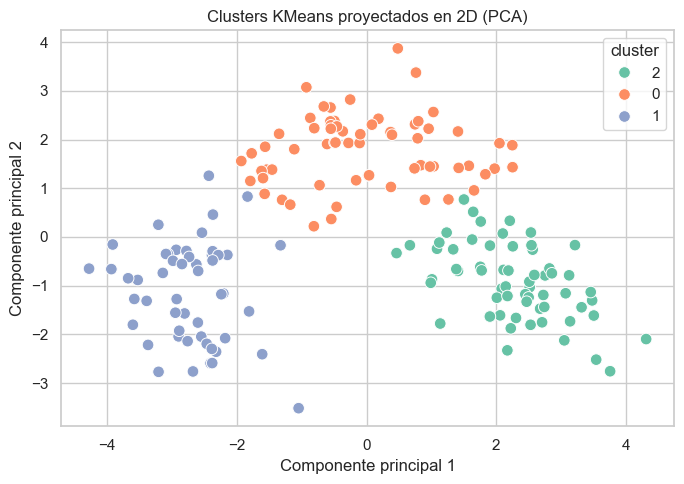

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pc1": X_2d[:, 0],
    "pc2": X_2d[:, 1],
    "cluster": clusters.astype(str),
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", palette="Set2", s=70)
plt.title("Clusters KMeans proyectados en 2D (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="cluster")
plt.tight_layout()
plt.show()

**Comentario:** La proyeccion PCA en 2D ayuda a comunicar la segmentacion, pero no reemplaza las metricas. Si hay traslape visual, no implica automaticamente un mal clustering: parte de la estructura puede vivir en dimensiones no visibles en el plano 2D.

## 7. Conclusiones

- KMeans segmenta por cercania a centroides, por eso escalar es obligatorio.
- Elegir `k` con un solo criterio puede ser riesgoso; conviene combinar codo + silueta + Calinski-Harabasz.
- En practica, la decision final de `k` debe equilibrar metricas y **interpretabilidad** de los segmentos.

**Siguiente paso sugerido:** contrastar este notebook con modelos de clustering alternativos (por ejemplo, DBSCAN o clustering jerarquico) para comparar sensibilidad a forma y densidad de grupos.